# TP 2 · Tres hipótesis sobre el dataset canónico

**Grupo 5K10-06** · Ciencia de Datos · UTN FRM · 2026

**Integrantes:** Carobolante, Alejo · Dallape, Vincenzo · Podesta, Isidro · Saini, Alejo

**Liga asignada en el TP1:** Bundesliga (Austria) — `league_id` = 80

---

### Las tres hipótesis de un vistazo

| # | Pregunta | Plantilla | Medida | Resultado | Zona | Movimientos |
|---|---|---|---|---|---|---|
| 1 | Responder | Asociación | Correlación de Pearson | 0,502 → 0,830 | Amarillo → Verde | 1 (cambiar la escala) |
| 2 | Predecir | Comparación | Separación estandarizada | 0,086 | Rojo | ninguno |
| 3 | Responder | Composición | η² (razón de correlación) | 0,232 → 0,106 | Amarillo (inconclusa) | 1 (partir la población) |

La hipótesis 3 es la que filtra por nuestra `league_id`.

El análisis exploratorio y la auditoría del dataset están resueltos en los notebooks de la práctica y no se repiten acá. Este notebook arranca donde termina aquél: eligiendo preguntas y contestándolas.

## 0 · Preparación

### Cómo se carga el dataset

La celda de abajo baja el CSV canónico desde Google Drive con `gdown`, el mismo mecanismo que usan los notebooks de la práctica (`Intro_a_Pandas.ipynb`, `EDA_del_dataset_canonico.ipynb`, `Hipotesis_sobre_el_canonico.ipynb`). Solo descarga una vez: si `fifa_canonico_2026-07-23.csv` ya existe al lado del notebook, lo reutiliza.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

# Dataset canónico de la materia: snapshot 260046 de sofifa (23/07/2026),
# 18.936 jugadores x 90 columnas. Mismo mecanismo de descarga que los
# notebooks de la práctica: Google Drive vía gdown.
ARCHIVO = "fifa_canonico_2026-07-23.csv"
ID_DRIVE = "1cF30_fSvxNKpK5-AKJlzUqLHZTTUf0ls"

if not os.path.exists(ARCHIVO):
    !gdown $ID_DRIVE -O $ARCHIVO

df = pd.read_csv(ARCHIVO, low_memory=False)
print("Filas y columnas:", df.shape)
print("Snapshot:", df["fifa_update_date"].iloc[0])

Using cookies from C:\Users\isidr\.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1cF30_fSvxNKpK5-AKJlzUqLHZTTUf0ls
To: C:\cdtp\CienciaDatos-BaseCanonica-TPs\fifa_canonico_2026-07-23.csv

  0%|          | 0.00/9.56M [00:00<?, ?B/s]
  5%|5         | 524k/9.56M [00:00<00:08, 1.01MB/s]
 11%|#         | 1.05M/9.56M [00:00<00:07, 1.18MB/s]
 16%|#6        | 1.57M/9.56M [00:01<00:09, 828kB/s] 
 22%|##1       | 2.10M/9.56M [00:02<00:08, 839kB/s]
 27%|##7       | 2.62M/9.56M [00:02<00:07, 964kB/s]
 33%|###2      | 3.15M/9.56M [00:03<00:08, 742kB/s]
 38%|###8      | 3.67M/9.56M [00:04<00:07, 745kB/s]
 44%|####3     | 4.19M/9.56M [00:05<00:07, 674kB/s]
 49%|####9     | 4.72M/9.56M [00:06<00:08, 541kB/s]
 55%|#####4    | 5.24M/9.56M [00:09<00:12, 358kB/s]
 60%|######    | 5.77M/9.56M [00:12<00:15, 251kB/s]
 66%|######5   | 6.29M/9.56M [00:14<00:11, 274kB/s]
 71%|#######1  | 6.82M/9.56M [00:16<00:10, 252kB/s]
 77%|#######6  | 7.34M/9.56M [00:19<00:09, 242kB/s]
 82%|####

Filas y columnas: (18936, 90)
Snapshot: 2026-07-23


### Nuestra liga

Filtramos por `league_id`, no por el nombre, como pide el enunciado.

In [2]:
LIGA_ID = 80

liga = df[df["league_id"] == LIGA_ID].copy()
print("league_id:", LIGA_ID)
print("Liga:", liga["league_name"].iloc[0], "|", liga["league_country"].iloc[0])
print("Jugadores:", len(liga), "| Clubes:", liga["club_name"].nunique())

league_id: 80
Liga: Bundesliga | Austria
Jugadores: 348 | Clubes: 12


### El semáforo y las medidas

Cada plantilla tiene **una** medida, y la medida se elige antes de ver el resultado. Los cortes se aplican sobre el valor absoluto: el signo indica dirección y se lee aparte.

| Medida | Cuándo se usa | Rojo | Amarillo | Verde |
|---|---|---|---|---|
| Separación estandarizada | Una numérica entre **dos** grupos | < 0,20 | 0,20 – 0,80 | > 0,80 |
| η² (razón de correlación) | Una numérica entre **muchos** grupos | < 0,05 | 0,05 – 0,25 | > 0,25 |
| Correlación | **Dos** numéricas | < 0,20 | 0,20 – 0,60 | > 0,60 |
| Brecha Spearman − Pearson | Detectar que la relación no es recta | < 0,05 | 0,05 – 0,15 | > 0,15 |

Con 18.936 filas casi cualquier diferencia da estadísticamente significativa. El semáforo no pregunta si el efecto existe, pregunta si es lo bastante grande como para cambiar una decisión.

In [3]:
CORTES = {
    "separacion":  (0.20, 0.80),
    "eta2":        (0.05, 0.25),
    "correlacion": (0.20, 0.60),
    "brecha":      (0.05, 0.15),
}


def zona(valor, medida):
    """Devuelve ROJO / AMARILLO / VERDE según los cortes de la medida."""
    corte_rojo, corte_verde = CORTES[medida]
    v = abs(valor)
    if v < corte_rojo:
        return "ROJO"
    if v < corte_verde:
        return "AMARILLO"
    return "VERDE"


def semaforo(etiqueta, valor, medida):
    z = zona(valor, medida)
    print(f"{etiqueta:<46s} {valor:+.3f}   ->  {z}")
    return z


def spearman(a, b):
    """Spearman es Pearson sobre los rangos. Lo calculamos así para no
    depender de scipy y que el notebook corra en cualquier máquina."""
    return a.rank().corr(b.rank())


def separacion_estandarizada(a, b):
    """d de Cohen: diferencia de medias en unidades de desvío combinado."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    s_comb = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s_comb


def eta_cuadrado(datos, numerica, grupo):
    """Proporción de la variación total de `numerica` que se explica por
    la pertenencia a cada `grupo`."""
    y = datos[numerica].astype(float)
    media_global = y.mean()
    sc_total = ((y - media_global) ** 2).sum()
    sc_entre = (
        datos.groupby(grupo, observed=True)[numerica]
        .apply(lambda s: len(s) * (s.astype(float).mean() - media_global) ** 2)
        .sum()
    )
    return sc_entre / sc_total


print("Funciones listas.")

Funciones listas.


---

# Hipótesis 1 · ¿Qué determina el valor de un jugador?

**Pregunta: responder.** Es una pregunta de negocio y termina en una conclusión sobre cómo tratar la variable.

### 1. La afirmación

> En el dataset canónico, el valor de mercado de un jugador (`value_eur`) está asociado a su potencial (`potential`): los jugadores con mayor techo de crecimiento valen más.

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero una correlación de Pearson **amarilla, más floja que la del `overall`** -- calculo algo entre 0,35 y 0,45. El `potential` es una proyección: el techo que el juego calcula que un jugador podría llegar a alcanzar, no lo que ya rinde hoy. El mercado paga sobre todo por el presente -- minutos, nivel actual, contrato -- así que esperaría que el potencial explique menos la cotización real que un indicador de nivel actual. También espero una nube más ruidosa que una relación pareja: hay juveniles con potencial altísimo y valor todavía bajo porque recién debutan, y veteranos con el potencial ya agotado (`potential` = `overall`) pero valor alto por trayectoria.

### 3. Cómo la mido

- **Plantilla:** asociación. La afirmación relaciona **dos variables numéricas**.
- **Medida:** correlación de Pearson entre `potential` y `value_eur`. Cortes 0,20 / 0,60.
- **Gráfico:** dispersión de `value_eur` contra `potential`.

Reporto además la correlación de Spearman para tener la **brecha Spearman − Pearson**, que es el diagnóstico de si la relación es recta o no. La brecha no reemplaza a la medida de la plantilla: sirve para elegir el movimiento si el resultado cae en amarillo.

In [4]:
# 11 jugadores tienen value_eur = 0 (sin valor publicado en la fuente).
# Se excluyen: un valor de cero no es un precio bajo, es un dato ausente.
sin_valor = (df["value_eur"] == 0).sum()
h1 = df[df["value_eur"] > 0].copy()
print(f"Excluidos por value_eur = 0: {sin_valor}   |   Quedan: {len(h1)}")

r_pearson = h1["potential"].corr(h1["value_eur"])
r_spearman = spearman(h1["potential"], h1["value_eur"])
brecha = abs(r_spearman) - abs(r_pearson)

print()
z1 = semaforo("Pearson  potential ~ value_eur", r_pearson, "correlacion")
print(f"{'Spearman potential ~ value_eur':<46s} {r_spearman:+.3f}")
semaforo("Brecha Spearman - Pearson", brecha, "brecha")

Excluidos por value_eur = 0: 11   |   Quedan: 18925

Pearson  potential ~ value_eur                 +0.502   ->  AMARILLO
Spearman potential ~ value_eur                 +0.803
Brecha Spearman - Pearson                      +0.301   ->  VERDE


'VERDE'

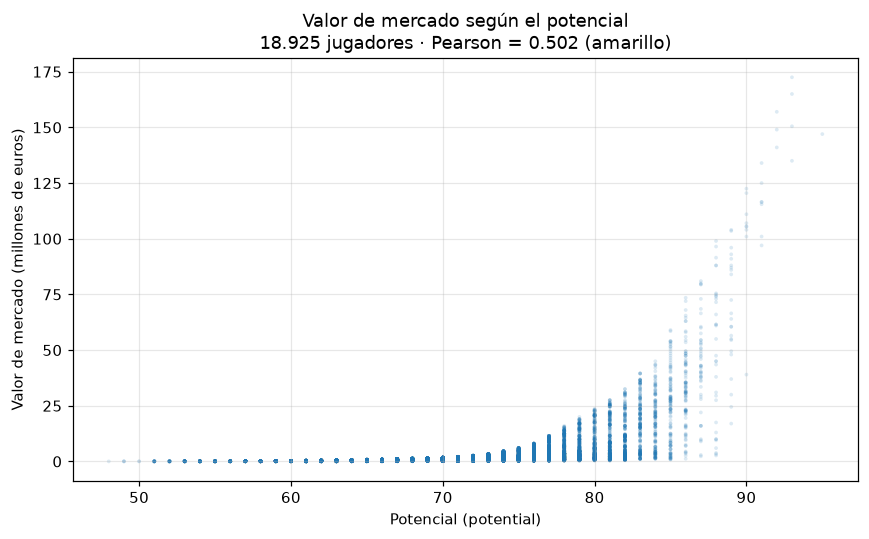

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(h1["potential"], h1["value_eur"] / 1e6, s=6, alpha=0.15,
           color="#1f77b4", edgecolors="none")
ax.set_title("Valor de mercado según el potencial\n"
             f"18.925 jugadores · Pearson = {r_pearson:.3f} (amarillo)")
ax.set_xlabel("Potencial (potential)")
ax.set_ylabel("Valor de mercado (millones de euros)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **Pearson** `potential` ~ `value_eur` | **+0,502** | **AMARILLO** |
| Spearman | +0,803 | — |
| Brecha Spearman − Pearson | +0,301 | por encima de 0,15 |

La correlación quedó en amarillo, pero **más alta** de lo que esperaba: calculaba algo entre 0,35 y 0,45, pensando que el potencial iba a pesar bastante menos que un indicador de nivel actual. El gráfico también me sorprendió del otro lado: no es una nube más ruidosa que la del `overall`, es una nube igual de ordenada, sólo que curva. Se queda pegada al piso hasta un `potential` de 70, ahí se despega, y a partir de 80 se dispara -- la misma forma que tiene `overall`. Pearson mide parecido a una **recta**, y esto no es una recta. Spearman, que sólo mira el orden, da 0,803: el orden se respeta bastante bien, lo que falla es la forma.

### 5. Qué movimiento hice

**Cambiar la escala.** Uno solo.

El enunciado dice que ese movimiento corresponde cuando la nube sube de forma ordenada pero curva y la brecha entre Spearman y Pearson es grande. Es exactamente el caso, con una brecha de 0,301 contra un corte de 0,15. Los otros dos movimientos no aplicaban: no hay grupos que se despeguen, así que no había nada que partir, y el resultado no contradice nada conocido, así que no había una tercera variable que controlar.

Aplico logaritmo en base 10 al valor y vuelvo a medir.

In [6]:
h1["log_value"] = np.log10(h1["value_eur"])

r_pearson_log = h1["potential"].corr(h1["log_value"])
z1_post = semaforo("Pearson  potential ~ log10(value_eur)", r_pearson_log, "correlacion")
print(f"\nAntes del movimiento: {r_pearson:+.3f} ({z1})")
print(f"Despues del movimiento: {r_pearson_log:+.3f} ({z1_post})")

Pearson  potential ~ log10(value_eur)          +0.830   ->  VERDE

Antes del movimiento: +0.502 (AMARILLO)
Despues del movimiento: +0.830 (VERDE)


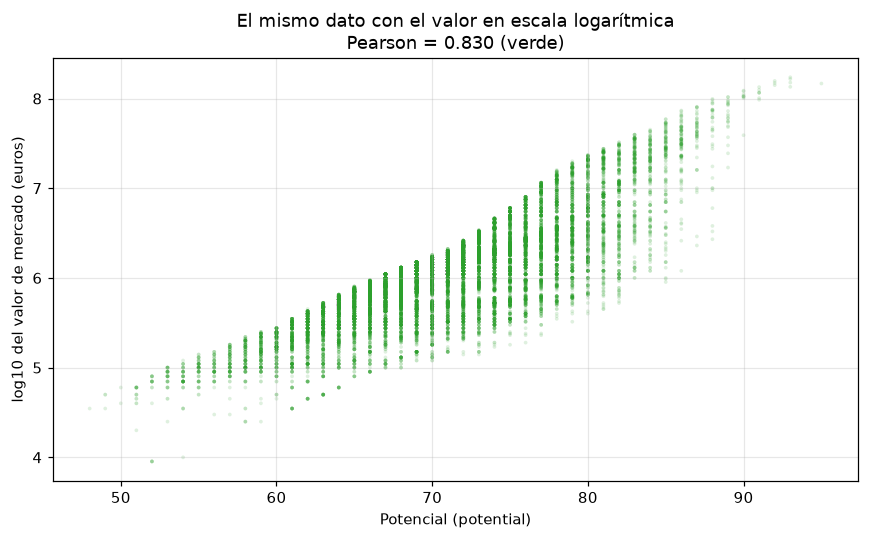

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(h1["potential"], h1["log_value"], s=6, alpha=0.15,
           color="#2ca02c", edgecolors="none")
ax.set_title("El mismo dato con el valor en escala logarítmica\n"
             f"Pearson = {r_pearson_log:.3f} (verde)")
ax.set_xlabel("Potencial (potential)")
ax.set_ylabel("log10 del valor de mercado (euros)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Con el valor en escala logarítmica la nube se endereza y la correlación pasa de **0,502 (amarillo)** a **0,830 (verde)**. La relación siempre estuvo ahí; lo que estaba mal era la escala en la que la mirábamos.

### 6. Qué hago con eso

**`value_eur` hay que transformarla: entra al modelo en escala logarítmica, nunca cruda.**

Tres consecuencias concretas:

1. Cualquier método que asuma relaciones rectas, y la regresión lineal es el caso obvio, va a subestimar el peso del `potential` si recibe el valor en euros.
2. En escala cruda, un puñado de jugadores de más de 100 millones domina el error y aplasta a los 18.900 restantes. En logaritmo, todos pesan parecido.
3. `potential` queda confirmada como variable fuerte y se conserva -- casi tan fuerte como el `overall`, pero mirando el techo futuro en vez del nivel actual. La misma lógica vale para `wage_eur` y `release_clause_eur`, que son montos de dinero con la misma forma de distribución.

---

# Hipótesis 2 · ¿La altura sirve para distinguir puestos del mediocampo?

**Pregunta: predecir.** Apunta al objetivo de la Unidad 3, que es la posición, y termina en una decisión sobre si la columna entra o no.

### 1. La afirmación

> Entre los mediocampistas defensivos (`best_position` = `CDM`) y los mediocampistas centrales (`best_position` = `CM`), la altura (`height_cm`) difiere: los CDM son más altos.

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero una separación **moderada, alrededor de 0,40 o 0,50**, o sea amarillo. El CDM juega más cerca del área propia, disputa más pelotas aéreas y suele cubrir a los delanteros centro en las jugadas paradas, así que esperaría entre dos y tres centímetros de diferencia de media. No espero verde, porque los dos son puestos de mediocampo y muchos jugadores alternan entre ambos.

En el gráfico espero dos campanas parecidas, con la de los CDM corrida un poco a la derecha.

### 3. Cómo la mido

- **Plantilla:** comparación. La afirmación compara una **numérica** entre **dos grupos**.
- **Medida:** separación estandarizada, la d de Cohen entre CDM y CM sobre `height_cm`. Cortes 0,20 / 0,80.
- **Gráfico:** histogramas superpuestos de la altura en los dos grupos.

Elegí la separación estandarizada y no la diferencia de medias en centímetros porque los centímetros no se pueden comparar contra el semáforo: hacen falta unidades de desvío.

In [8]:
cdm = df[df["best_position"] == "CDM"]["height_cm"]
cm = df[df["best_position"] == "CM"]["height_cm"]

print(f"CDM: n = {len(cdm):5d}   media = {cdm.mean():6.2f} cm   desvío = {cdm.std(ddof=1):.2f}")
print(f"CM : n = {len(cm):5d}   media = {cm.mean():6.2f} cm   desvío = {cm.std(ddof=1):.2f}")
print(f"\nDiferencia de medias: {cdm.mean() - cm.mean():.2f} cm")
print()

d_h2 = separacion_estandarizada(cdm, cm)
z2 = semaforo("Separación estandarizada CDM vs CM (altura)", d_h2, "separacion")

CDM: n =  1289   media = 180.50 cm   desvío = 5.65
CM : n =  1193   media = 180.02 cm   desvío = 5.60

Diferencia de medias: 0.48 cm

Separación estandarizada CDM vs CM (altura)    +0.086   ->  ROJO


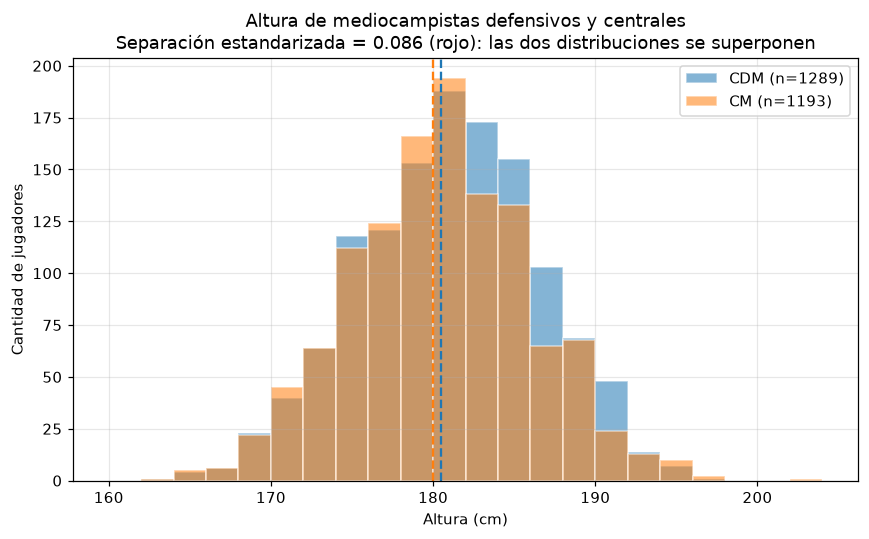

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(160, 205, 2)
ax.hist(cdm, bins=bins, alpha=0.55, label=f"CDM (n={len(cdm)})",
        color="#1f77b4", edgecolor="white")
ax.hist(cm, bins=bins, alpha=0.55, label=f"CM (n={len(cm)})",
        color="#ff7f0e", edgecolor="white")
ax.axvline(cdm.mean(), color="#1f77b4", linestyle="--", linewidth=1.5)
ax.axvline(cm.mean(), color="#ff7f0e", linestyle="--", linewidth=1.5)
ax.set_title("Altura de mediocampistas defensivos y centrales\n"
             f"Separación estandarizada = {d_h2:.3f} (rojo): las dos distribuciones se superponen")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Cantidad de jugadores")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **Separación estandarizada** CDM vs CM en `height_cm` | **+0,086** | **ROJO** |

- CDM: 1.289 jugadores, media 180,50 cm
- CM: 1.193 jugadores, media 180,02 cm
- Diferencia: **0,48 cm**, menos de medio centímetro

**La hipótesis queda refutada.** Las dos líneas de media están prácticamente pegadas y los histogramas se superponen casi por completo. Media distinta hay, y con casi 2.500 jugadores seguro daría estadísticamente significativa, pero medio centímetro sobre un desvío de 5,6 cm no cambia ninguna decisión. Es justo el caso que el semáforo está para atajar.

### 5. Qué movimiento hice

**Ninguno.** El resultado es rojo y en rojo se termina: el efecto no está.

### 6. Qué hago con eso

**`height_cm` no separa el mediocampo, así que no alcanza por sí sola para el modelo de posición.**

La columna igual **se conserva**, porque el problema no es la columna sino la frontera concreta que le pedimos distinguir. Para verificarlo medimos la misma columna en otra frontera, y ahí sí funciona:

In [10]:
centrales = df[df["best_position"] == "CB"]["height_cm"]
laterales = df[df["best_position"].isin(["LB", "RB"])]["height_cm"]

d_control = separacion_estandarizada(centrales, laterales)
print(f"CB       : n = {len(centrales):5d}   media = {centrales.mean():.2f} cm")
print(f"LB / RB  : n = {len(laterales):5d}   media = {laterales.mean():.2f} cm")
print()
semaforo("Separación estandarizada CB vs laterales (altura)", d_control, "separacion")
print("\nComprobación de apoyo para el campo 6, no es la medida de la hipótesis.")

CB       : n =  3769   media = 186.97 cm
LB / RB  : n =  2067   media = 178.55 cm

Separación estandarizada CB vs laterales (altura) +1.714   ->  VERDE

Comprobación de apoyo para el campo 6, no es la medida de la hipótesis.


La misma columna que no distingue CDM de CM separa muy bien a los centrales de los laterales, con una separación de 1,71 en verde. La conclusión no es «la altura no sirve», es **«la altura sirve para unas fronteras y no para otras»**.

Decisión para la Unidad 3: `height_cm` entra al modelo, pero **no puede ser la que resuelva el mediocampo**. Para separar CDM de CM hay que apoyarse en atributos de rol, no de físico, como `defending_standing_tackle` o `mentality_interceptions`. Y si el modelo confunde esos dos puestos, ya sabemos que agregar variables de físico no lo va a arreglar.

---

# Hipótesis 3 · ¿Nuestra liga se destaca en valor de mercado dentro del dataset canónico?

**Pregunta: responder.** Es la hipótesis que usa la liga que nos tocó en el TP1, comparada contra el resto del dataset canónico completo.

### 1. La afirmación

> Dentro del dataset canónico completo, el valor de mercado de un jugador (`value_eur`) depende en buena medida de la liga en la que juega (`league_id`): hay ligas que valen sistemáticamente más que otras, y nuestra liga del TP1 (Bundesliga de Austria, `league_id` = 80) no es una excepción a esa brecha entre ligas.

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero un η² **alto, verde, por encima de 0,30**. El dataset mezcla las cinco ligas top de Europa (Premier League, La Liga, Serie A, Bundesliga alemana, Ligue 1) con decenas de ligas mucho más chicas, y esa diferencia de nivel entre ligas debería pesar más que cualquier variación interna a una sola liga. Para nuestra liga en particular, esperaría quedar entre las últimas del ranking: la Bundesliga de Austria es una liga chica, sin la exposición económica de las cinco grandes.

### 3. Cómo la mido

- **Plantilla:** composición. La afirmación pregunta **cómo se reparte** la variación de una numérica entre las categorías en las que se compone la población, que acá son las **52 ligas** del dataset canónico completo, no los clubes de una sola liga.
- **Medida:** η², la razón de correlación, que es la proporción de la variación total de `value_eur` que se explica por `league_id`. Cortes 0,05 / 0,25.
- **Gráfico:** histograma de la mediana de `value_eur` por liga (52 puntos), con nuestra liga marcada.

Uso η² y no la separación estandarizada porque las categorías son **52 ligas, no dos grupos**: juntar "nuestra liga" contra "todas las demás promediadas" en un solo bloque escondería que las ligas no son parecidas entre sí, y además esa comparación de dos grupos ya es la plantilla de la Hipótesis 2.

In [11]:
print("Ligas en el dataset:", df["league_id"].nunique())
print("Jugadores en total:", len(df))
print("Jugadores en nuestra liga (80):", len(liga))
print()

eta2_ligas = eta_cuadrado(df, "value_eur", "league_id")
z3 = semaforo("eta² de league_id sobre value_eur (52 ligas)", eta2_ligas, "eta2")
print()

medianas_liga = df.groupby("league_id")["value_eur"].median().sort_values(ascending=False)
puesto_80 = list(medianas_liga.index).index(80) + 1
print(f"Mediana de nuestra liga (80): {medianas_liga.loc[80]:,.0f} EUR")
print(f"Puesto de nuestra liga: {puesto_80} de {len(medianas_liga)} ligas (de mayor a menor mediana)")

Ligas en el dataset: 52
Jugadores en total: 18936
Jugadores en nuestra liga (80): 348

eta² de league_id sobre value_eur (52 ligas)   +0.232   ->  AMARILLO

Mediana de nuestra liga (80): 950,000 EUR
Puesto de nuestra liga: 26 de 52 ligas (de mayor a menor mediana)


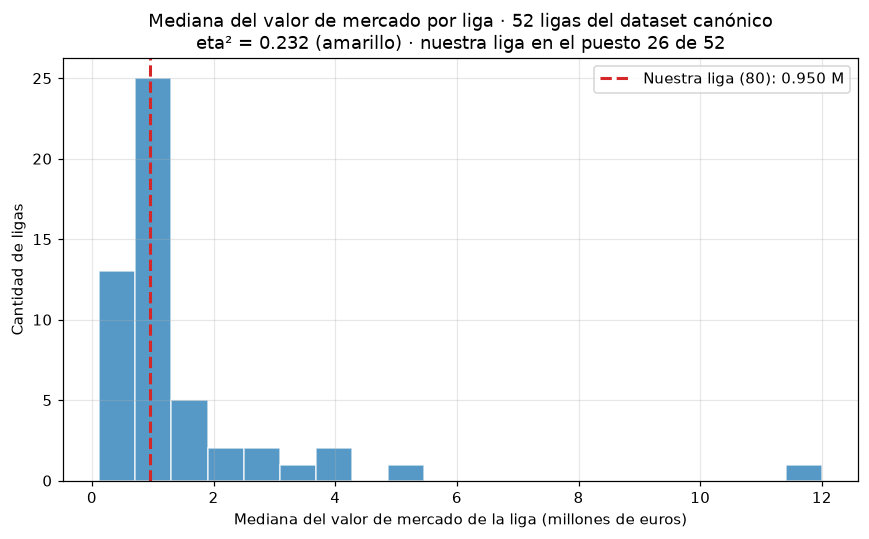

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(medianas_liga.values / 1e6, bins=20, color="#1f77b4", alpha=0.75, edgecolor="white")
ax.axvline(medianas_liga.loc[80] / 1e6, color="#d62728", linestyle="--", linewidth=2,
           label=f"Nuestra liga (80): {medianas_liga.loc[80] / 1e6:.3f} M")
ax.set_title("Mediana del valor de mercado por liga · 52 ligas del dataset canónico\n"
             f"eta² = {eta2_ligas:.3f} (amarillo) · nuestra liga en el puesto {puesto_80} de {len(medianas_liga)}")
ax.set_xlabel("Mediana del valor de mercado de la liga (millones de euros)")
ax.set_ylabel("Cantidad de ligas")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **η²** de `league_id` sobre `value_eur`, en las 52 ligas del dataset | **0,232** | **AMARILLO** |

El η² da amarillo, más bajo de lo que esperaba: la liga explica una parte real pero no dominante de la variación del valor. Y nuestra liga no quedó donde esperaba: la Bundesliga de Austria (mediana ≈ 950.000) queda en el puesto 26 de 52, casi exactamente la mitad de la tabla — no es de las últimas.

El gráfico explica por qué el η² no es más alto de lo que es, y por qué tampoco es bajo: la mayoría de las 52 medianas se apiña en una franja angosta, pero hay un puñado de barras sueltas muy a la derecha, separadas del resto. Eso es justo lo que amarillo está para señalar: no hay un solo régimen, hay dos.

### 5. Qué movimiento hice

**Partir la población.** El gráfico muestra grupos que se comportan distinto: un puñado de ligas (los nombres, al ordenar por mediana, son las cinco grandes de Europa) se despega muy por encima del resto, que se agrupa en una franja mucho más angosta. El enunciado dice que ese movimiento corresponde cuando el gráfico muestra grupos que no se comportan igual, que es exactamente el caso acá. Los otros dos movimientos no aplicaban: no hay una tercera variable obvia que controlar (el resultado no contradice nada que supiéramos), y no hay una curva que enderezar (esto no es una relación entre dos numéricas).

Repito la medida excluyendo a las cinco ligas que se despegan, para ver qué queda del efecto de la liga entre las 47 restantes.

In [13]:
top5_ids = medianas_liga.index[:5].tolist()
print("Las 5 ligas que se despegan:", top5_ids)

resto_ligas = df[~df["league_id"].isin(top5_ids)].copy()
eta2_resto = eta_cuadrado(resto_ligas, "value_eur", "league_id")
z3_post = semaforo("eta² de league_id sobre value_eur (47 ligas, sin las 5 grandes)", eta2_resto, "eta2")

medianas_resto = resto_ligas.groupby("league_id")["value_eur"].median().sort_values(ascending=False)
puesto_80_resto = list(medianas_resto.index).index(80) + 1
print(f"\nPuesto de nuestra liga entre las 47 restantes: {puesto_80_resto} de {len(medianas_resto)}")
print(f"Mediana de nuestra liga: {medianas_resto.loc[80]:,.0f}   mediana del resto: {medianas_resto.median():,.0f}")
print(f"\nAntes del movimiento (52 ligas): {eta2_ligas:.3f} ({z3})")
print(f"Despues del movimiento (47 ligas, sin las 5 grandes): {eta2_resto:.3f} ({z3_post})")

Las 5 ligas que se despegan: [13, 53, 31, 19, 16]


eta² de league_id sobre value_eur (47 ligas, sin las 5 grandes) +0.106   ->  AMARILLO

Puesto de nuestra liga entre las 47 restantes: 21 de 47
Mediana de nuestra liga: 950,000   mediana del resto: 925,000

Antes del movimiento (52 ligas): 0.232 (AMARILLO)
Despues del movimiento (47 ligas, sin las 5 grandes): 0.106 (AMARILLO)


El η² baja de 0,232 a 0,106 al sacar a las cinco ligas grandes — sigue en amarillo, no cruza a rojo, así que la conclusión sobre el efecto puro de la liga, más allá de esas cinco, **queda inconclusa**. Es exactamente el caso que el enunciado avisa que puede pasar, y no hay que forzar un segundo movimiento para buscar un verde o un rojo que no está: partiendo el dataset lo suficiente siempre aparece un subgrupo donde el efecto se ve distinto, y eso no significaría nada. Dentro de las 47 ligas restantes, nuestra liga queda en el puesto 21 de 47 (mediana ≈ 950.000 contra una mediana del grupo de 925.000) — de nuevo casi exactamente en el medio.

### 6. Qué hago con eso

**La brecha grande está en las cinco ligas top, no en nuestra liga ni en la comparación general.**

Dos consecuencias concretas:

1. `league_id` (y con él `league_name` y `league_country`, que ya salen del modelo por ser redundantes) no aporta nada para predecir la posición, que es el objetivo de la Unidad 3: la liga es un dato de contexto económico del jugador, no de su rol en la cancha.
2. Si en algún momento se usa `value_eur` como variable de entrada, hay que tener presente que arrastra un efecto de liga concentrado en cinco casos extremos. Comparar el valor de un jugador de una de esas cinco ligas contra uno de cualquiera de las otras 47 -- incluida la nuestra -- mezcla calidad individual con el peso económico de jugar en una liga top. Dentro de las 47 restantes, en cambio, la liga aporta poco: ahí sí vale comparar el valor entre jugadores sin ese ajuste.

---

# Cierre · Qué le damos al modelo de la Unidad 3

**Entran.** `overall`, `potential` y los atributos de rol, que son los que separan puestos de verdad: `defending_marking_awareness`, `defending_standing_tackle`, `mentality_interceptions`, `skill_moves` y `pace`. `height_cm` también entra, pero sabiendo que resuelve la frontera entre centrales y laterales y no la del mediocampo.

**Entra transformada.** `value_eur` sólo en escala logarítmica. En euros crudos subestima su relación con la calidad y deja que un puñado de jugadores caros domine cualquier ajuste. Lo mismo corre para `wage_eur` y `release_clause_eur`.

**Salen.** `club_name` y las columnas de identidad, que son `player_id`, `short_name`, `long_name`, `player_url` y `player_face_url`. También `league_name` y `league_country`, que son redundantes con `league_id`.

**Quedó sin resolver.** No sabemos separar CDM de CM: la altura no lo hace y todavía no probamos si los atributos defensivos alcanzan. Tampoco medimos cuánto del efecto del club sobre el valor es en realidad efecto de la calidad de los jugadores que ese club puede pagar, que es una tercera variable que empuja a las dos cosas a la vez y habría que controlar.

---

### Nota sobre los resultados

Las tres hipótesis cayeron en zonas distintas, y ninguna de las tres dio lo que esperábamos. La primera esperaba amarillo bajo, más flojo que el del `overall`, y dio amarillo pero bastante más alto de lo previsto -- recién con el movimiento de escala se vio que la relación real era mucho más fuerte, sólo que curva. La segunda esperaba amarillo y dio rojo, o sea que quedó refutada. La tercera esperaba verde y dio amarillo, y ni partiendo la población se resolvió del todo: quedó inconclusa.

La que más información dejó fue la que falló. Descubrir que la altura no distingue el mediocampo evita que en la Unidad 3 perdamos tiempo buscando por el lado del físico un problema que es de rol.